## Imports

In [63]:
import sys
sys.path.append(r"C:\Users\ibf\Desktop\TFM\Nou_projecte")
from TFM.Utils.cnn_utils import *
from TFM.Utils.ocr_utils import *
import joblib

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\ibf\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
print(pytesseract.get_tesseract_version())

5.5.0.20241111


## Model Load

### TEXT Classifier

In [64]:
ROOT = Path('..').resolve().parent

# Base model folder
MODEL_PATH = ROOT / "TFM" / "Model_Notebooks" / "models" / "ocr_text_classifier_v3"

# Embedding model
embedding_model = SentenceTransformer(str(MODEL_PATH / "embedding_model"))

# Classifier
text_clf = joblib.load(str(MODEL_PATH / "orc_clf.joblib"))

# Class names
class_names = joblib.load(str(MODEL_PATH / "classes.joblib"))

# Config
with open(str(MODEL_PATH / "config.json"), "r", encoding="utf-8") as f:
    config = json.load(f)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2655.71it/s]


### CV Classifier

In [65]:
CLASS_NAMES_PATH = ROOT / "TFM" / "Models" / "class_names.json"

MODEL_DIR = ROOT / "TFM" / "Models"

MODEL_CANDIDATES = [
    "cnn_NEW_DATA_45epochs.pth",
    "cnn_NEW_DATA_20epochs.pth",
    "cnn_full_DATA_45epochs.pth",
    "custom_cnn_from_scratch_DA_fairness.pth",
    "custom_cnn_from_scratch_DA.pth",
    "custom_cnn_from_scratch_30epochs.pth",
    "custom_cnn_from_scratch.pth",
]

IMAGE_SIZE = (224, 224)
BORDER_CROP = 120
CONFIDENCE_THRESHOLD = 0.90

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD:.2f}")

Using device: cpu
Confidence threshold: 0.90


In [66]:
cv_clf, class_names, model_path = load_model_pipeline(
    model_dir=MODEL_DIR,
    class_names_path=CLASS_NAMES_PATH,
    model_candidates=MODEL_CANDIDATES,
    model_class=CustomCNN,
    device=device
)

## Predict for image

### Image path

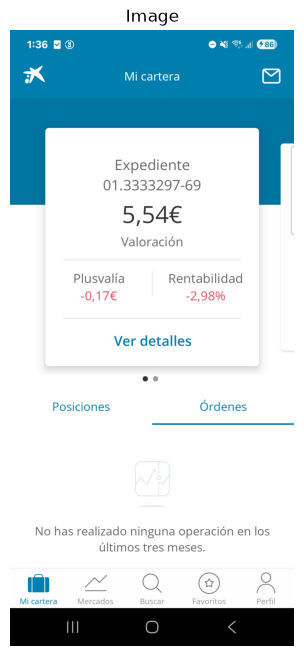

In [88]:
IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error funcional\Cartera\20260512013412_100149.png")

image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(5, 8))
plt.imshow(image)

plt.title(
    "Image"
)

plt.axis("off")
plt.show()


### Text prediction

In [89]:
text_results = predict_text_proba(
    image_path=IMAGE_PATH,
    model=embedding_model,
    clf=text_clf
)

for item in text_results["probabilities"]:
    print(f"{item['class']}: {item['confidence']:.4f}")

Error funcional: 0.9946
Error aplicativo: 0.0018
Banner aplicación: 0.0010
Timeout: 0.0008
Error terminal: 0.0006
Cierre aplicación: 0.0005
Indeterminado: 0.0004
Revisión circuito: 0.0003


### CV Prediction

In [90]:
base_train_transform, minority_train_transform, val_transform = get_transforms(
    image_size=IMAGE_SIZE,
    border_crop=BORDER_CROP
)

cv_results = predict_image_proba(
    image_path=IMAGE_PATH,
    model=cv_clf,
    class_names=class_names,
    inference_transform=val_transform,
    device=device
)

for r in cv_results:
    print(f"{r['class']}: {r['confidence']:.4f}")

Error funcional: 0.9707
Error aplicativo: 0.0083
Timeout: 0.0062
Revisión circuito: 0.0048
Error terminal: 0.0041
Banner aplicación: 0.0029
Indeterminado: 0.0016
Cierre aplicación: 0.0015


## Combining Strategy

In [91]:
print("Probabilites from the Computer Vision model:")
for r in cv_results:
    print(f"{r['class']}: {r['confidence']:.4f}")

print("\nProbabilities from the Text model:")
for item in text_results["probabilities"]:
    print(f"{item['class']}: {item['confidence']:.4f}")

Probabilites from the Computer Vision model:
Error funcional: 0.9707
Error aplicativo: 0.0083
Timeout: 0.0062
Revisión circuito: 0.0048
Error terminal: 0.0041
Banner aplicación: 0.0029
Indeterminado: 0.0016
Cierre aplicación: 0.0015

Probabilities from the Text model:
Error funcional: 0.9946
Error aplicativo: 0.0018
Banner aplicación: 0.0010
Timeout: 0.0008
Error terminal: 0.0006
Cierre aplicación: 0.0005
Indeterminado: 0.0004
Revisión circuito: 0.0003
